Loaded 5600 gap-level records from 1400 files


,group,time_center,gap,mean_total_snr,sem_total_snr,n_animals
0,CTR,40.5,5.0,3.054747,0.154382,6
1,CTR,40.5,10.0,3.214789,0.162468,6
2,CTR,40.5,20.0,3.832522,0.194294,6
3,CTR,40.5,30.0,11.232530,0.548233,6
4,CTR,41.5,5.0,3.149744,0.162284,6


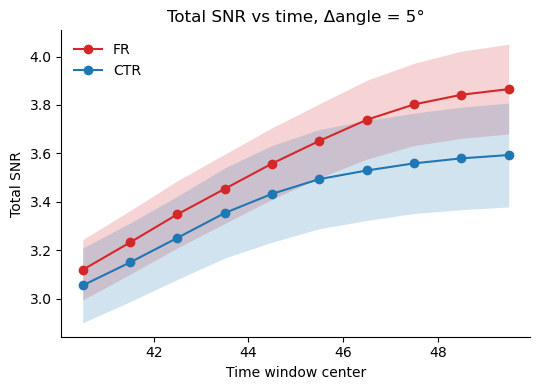

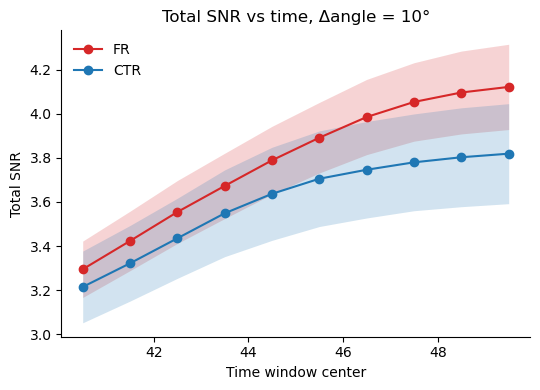

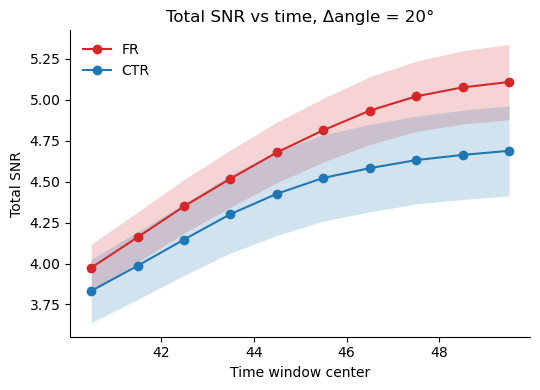

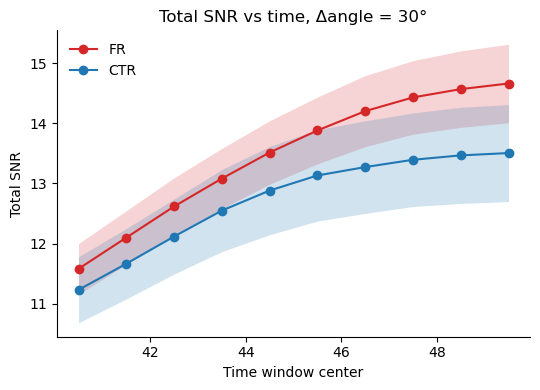

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("wishart_jun5_dynamic_equal40_sated")

records = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with open(path, "rb") as f:
        d = pickle.load(f)

    group = "FR" if path.name.startswith("FR_") else "CTR"
    gaps = np.atleast_1d(np.asarray(d["small_angle"], dtype=float))
    snr_small = np.asarray(d["snr_small"], dtype=float)

    # Expected current format: gap x angle_origin x sf x repeat_axis
    if snr_small.ndim == 3:
        snr_small = snr_small[None, ...]

    if snr_small.shape[0] != len(gaps):
        raise ValueError(f"{path.name}: snr_small shape {snr_small.shape} does not match gaps {gaps}")

    # "Total SNR": sum over angle origins, SFs, and trailing singleton/repeat axis.
    total_snr_by_gap = np.nanmean(snr_small.reshape(len(gaps), -1), axis=1)

    for gap, total_snr in zip(gaps, total_snr_by_gap):
        records.append({
            "group": group,
            "animal": int(d["animal"]),
            "repeat_idx": int(d["repeat_idx"]),
            "start": int(d["start"]),
            "stop": int(d["stop"]),
            "time_center": 0.5 * (int(d["start"]) + int(d["stop"])),
            "gap": float(gap),
            "total_snr": float(total_snr),
        })

df = pd.DataFrame(records)

# Average repeats within animal first, then compute group mean/SEM across animals.
animal_df = (
    df.groupby(["group", "animal", "start", "stop", "time_center", "gap"], as_index=False)
      ["total_snr"].mean()
)

summary = (
    animal_df.groupby(["group", "time_center", "gap"], as_index=False)
    .agg(
        mean_total_snr=("total_snr", "mean"),
        sem_total_snr=("total_snr", "sem"),
        n_animals=("animal", "nunique"),
    )
)

print(f"Loaded {len(df)} gap-level records from {len(list(RESULT_DIR.glob('*_overlaps_eigs.pkl')))} files")
display(summary.head())

colors = {"FR": "tab:red", "CTR": "tab:blue"}

for gap in sorted(summary["gap"].unique()):
    fig, ax = plt.subplots(figsize=(5.5, 4))

    for group in ["FR", "CTR"]:
        sub = summary[(summary["gap"] == gap) & (summary["group"] == group)].sort_values("time_center")
        x = sub["time_center"].to_numpy()
        y = sub["mean_total_snr"].to_numpy()
        sem = sub["sem_total_snr"].to_numpy()

        ax.plot(x, y, marker="o", label=group, color=colors[group])
        ax.fill_between(x, y - sem, y + sem, color=colors[group], alpha=0.2, linewidth=0)

    ax.set_title(f"Total SNR vs time, Δangle = {gap:g}°")
    ax.set_xlabel("Time window center")
    ax.set_ylabel("Total SNR")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

Loaded 5600 gap-level records


,group,time_center,gap,mean_total_snr,sem_total_snr,n_animals
0,CTR,40.5,5.0,3.054747,0.154382,6
1,CTR,40.5,10.0,3.214789,0.162468,6
2,CTR,40.5,20.0,3.832522,0.194294,6
3,CTR,40.5,30.0,11.232530,0.548233,6
4,CTR,41.5,5.0,3.149744,0.162284,6


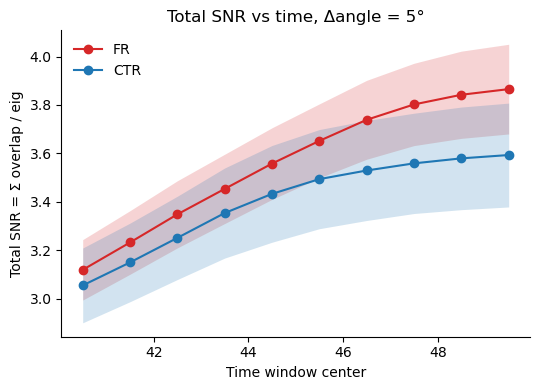

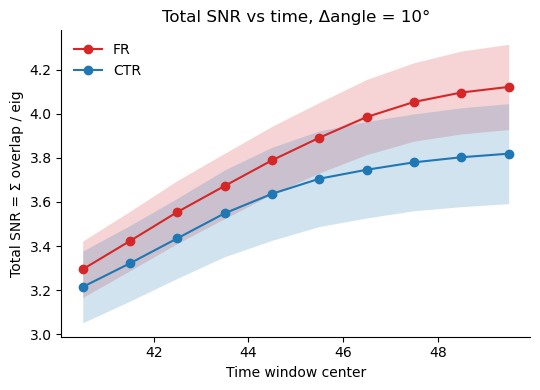

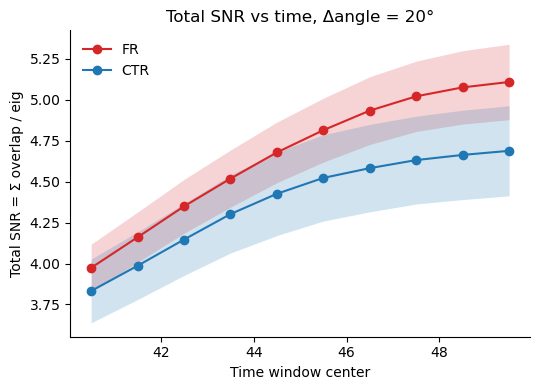

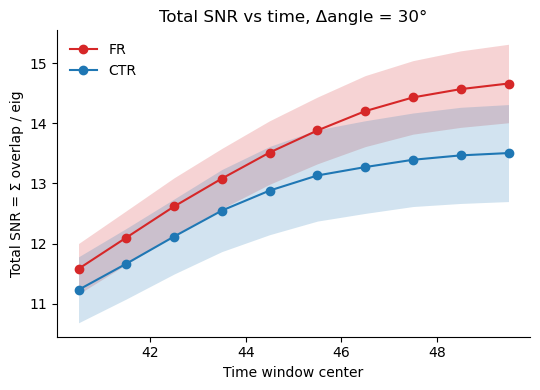

In [4]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("wishart_jun5_dynamic_equal40_sated")

def compute_snr_from_overlaps_eigs(overlaps, eigs):
    """
    Fisher-style SNR:
        sum_k overlap_k / eigenvalue_k

    overlaps_small shape:
        gap x angle x sf x eig x repeat_axis

    eigs_per_condition / top_evals shape:
        angle x sf x eig x repeat_axis
    """
    overlaps = np.asarray(overlaps, dtype=float)
    eigs = np.asarray(eigs, dtype=float)

    eigs_pos = np.where(eigs > 1e-5, eigs, np.nan)

    # Broadcast eigs over the leading gap axis.
    if overlaps.ndim == eigs_pos.ndim + 1:
        eigs_pos = eigs_pos[None, ...]
    # sum just the top 20 modes
    K = 500
    # return np.nansum(overlaps / eigs_pos, axis=-2)
    return np.nansum(overlaps[..., :K, :] / eigs[..., :K, :], axis=-2)


records = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with open(path, "rb") as f:
        d = pickle.load(f)

    group = "FR" if path.name.startswith("FR_") else "CTR"

    gaps = np.atleast_1d(np.asarray(d["small_angle"], dtype=float))
    overlaps_small = np.asarray(d["overlaps_small"], dtype=float)
    eigs = np.asarray(d["eigs_per_condition"], dtype=float)

    snr_small = compute_snr_from_overlaps_eigs(overlaps_small, eigs)

    if snr_small.ndim == 3:
        snr_small = snr_small[None, ...]

    if snr_small.shape[0] != len(gaps):
        raise ValueError(
            f"{path.name}: snr_small shape {snr_small.shape} does not match gaps {gaps}"
        )

    # Total SNR per gap: sum over angle origins, SFs, and trailing repeat axis.
    total_snr_by_gap = np.nanmean(snr_small.reshape(len(gaps), -1), axis=1)

    for gap, total_snr in zip(gaps, total_snr_by_gap):
        records.append({
            "group": group,
            "animal": int(d["animal"]),
            "repeat_idx": int(d["repeat_idx"]),
            "start": int(d["start"]),
            "stop": int(d["stop"]),
            "time_center": 0.5 * (int(d["start"]) + int(d["stop"])),
            "gap": float(gap),
            "total_snr": float(total_snr),
        })

df = pd.DataFrame(records)

animal_df = (
    df.groupby(["group", "animal", "start", "stop", "time_center", "gap"], as_index=False)
      ["total_snr"].mean()
)

summary = (
    animal_df.groupby(["group", "time_center", "gap"], as_index=False)
    .agg(
        mean_total_snr=("total_snr", "mean"),
        sem_total_snr=("total_snr", "sem"),
        n_animals=("animal", "nunique"),
    )
)

print(f"Loaded {len(df)} gap-level records")
display(summary.head())

colors = {"FR": "tab:red", "CTR": "tab:blue"}

for gap in sorted(summary["gap"].unique()):
    fig, ax = plt.subplots(figsize=(5.5, 4))

    for group in ["FR", "CTR"]:
        sub = summary[
            (summary["gap"] == gap) &
            (summary["group"] == group)
        ].sort_values("time_center")

        x = sub["time_center"].to_numpy()
        y = sub["mean_total_snr"].to_numpy()
        sem = sub["sem_total_snr"].to_numpy()

        ax.plot(x, y, marker="o", label=group, color=colors[group])
        ax.fill_between(x, y - sem, y + sem, color=colors[group], alpha=0.2, linewidth=0)

    ax.set_title(f"Total SNR vs time, Δangle = {gap:g}°")
    ax.set_xlabel("Time window center")
    ax.set_ylabel("Total SNR = Σ overlap / eig")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

Loaded 5600 gap-level records from 1400 files
Gaps: [5.0, 10.0, 20.0, 30.0]
Fitted alpha = 0.747722
Target gap 30°, target time 0.250s, target perf 0.800
FR info=3.8274, CTR info=3.7511, mean=3.7892


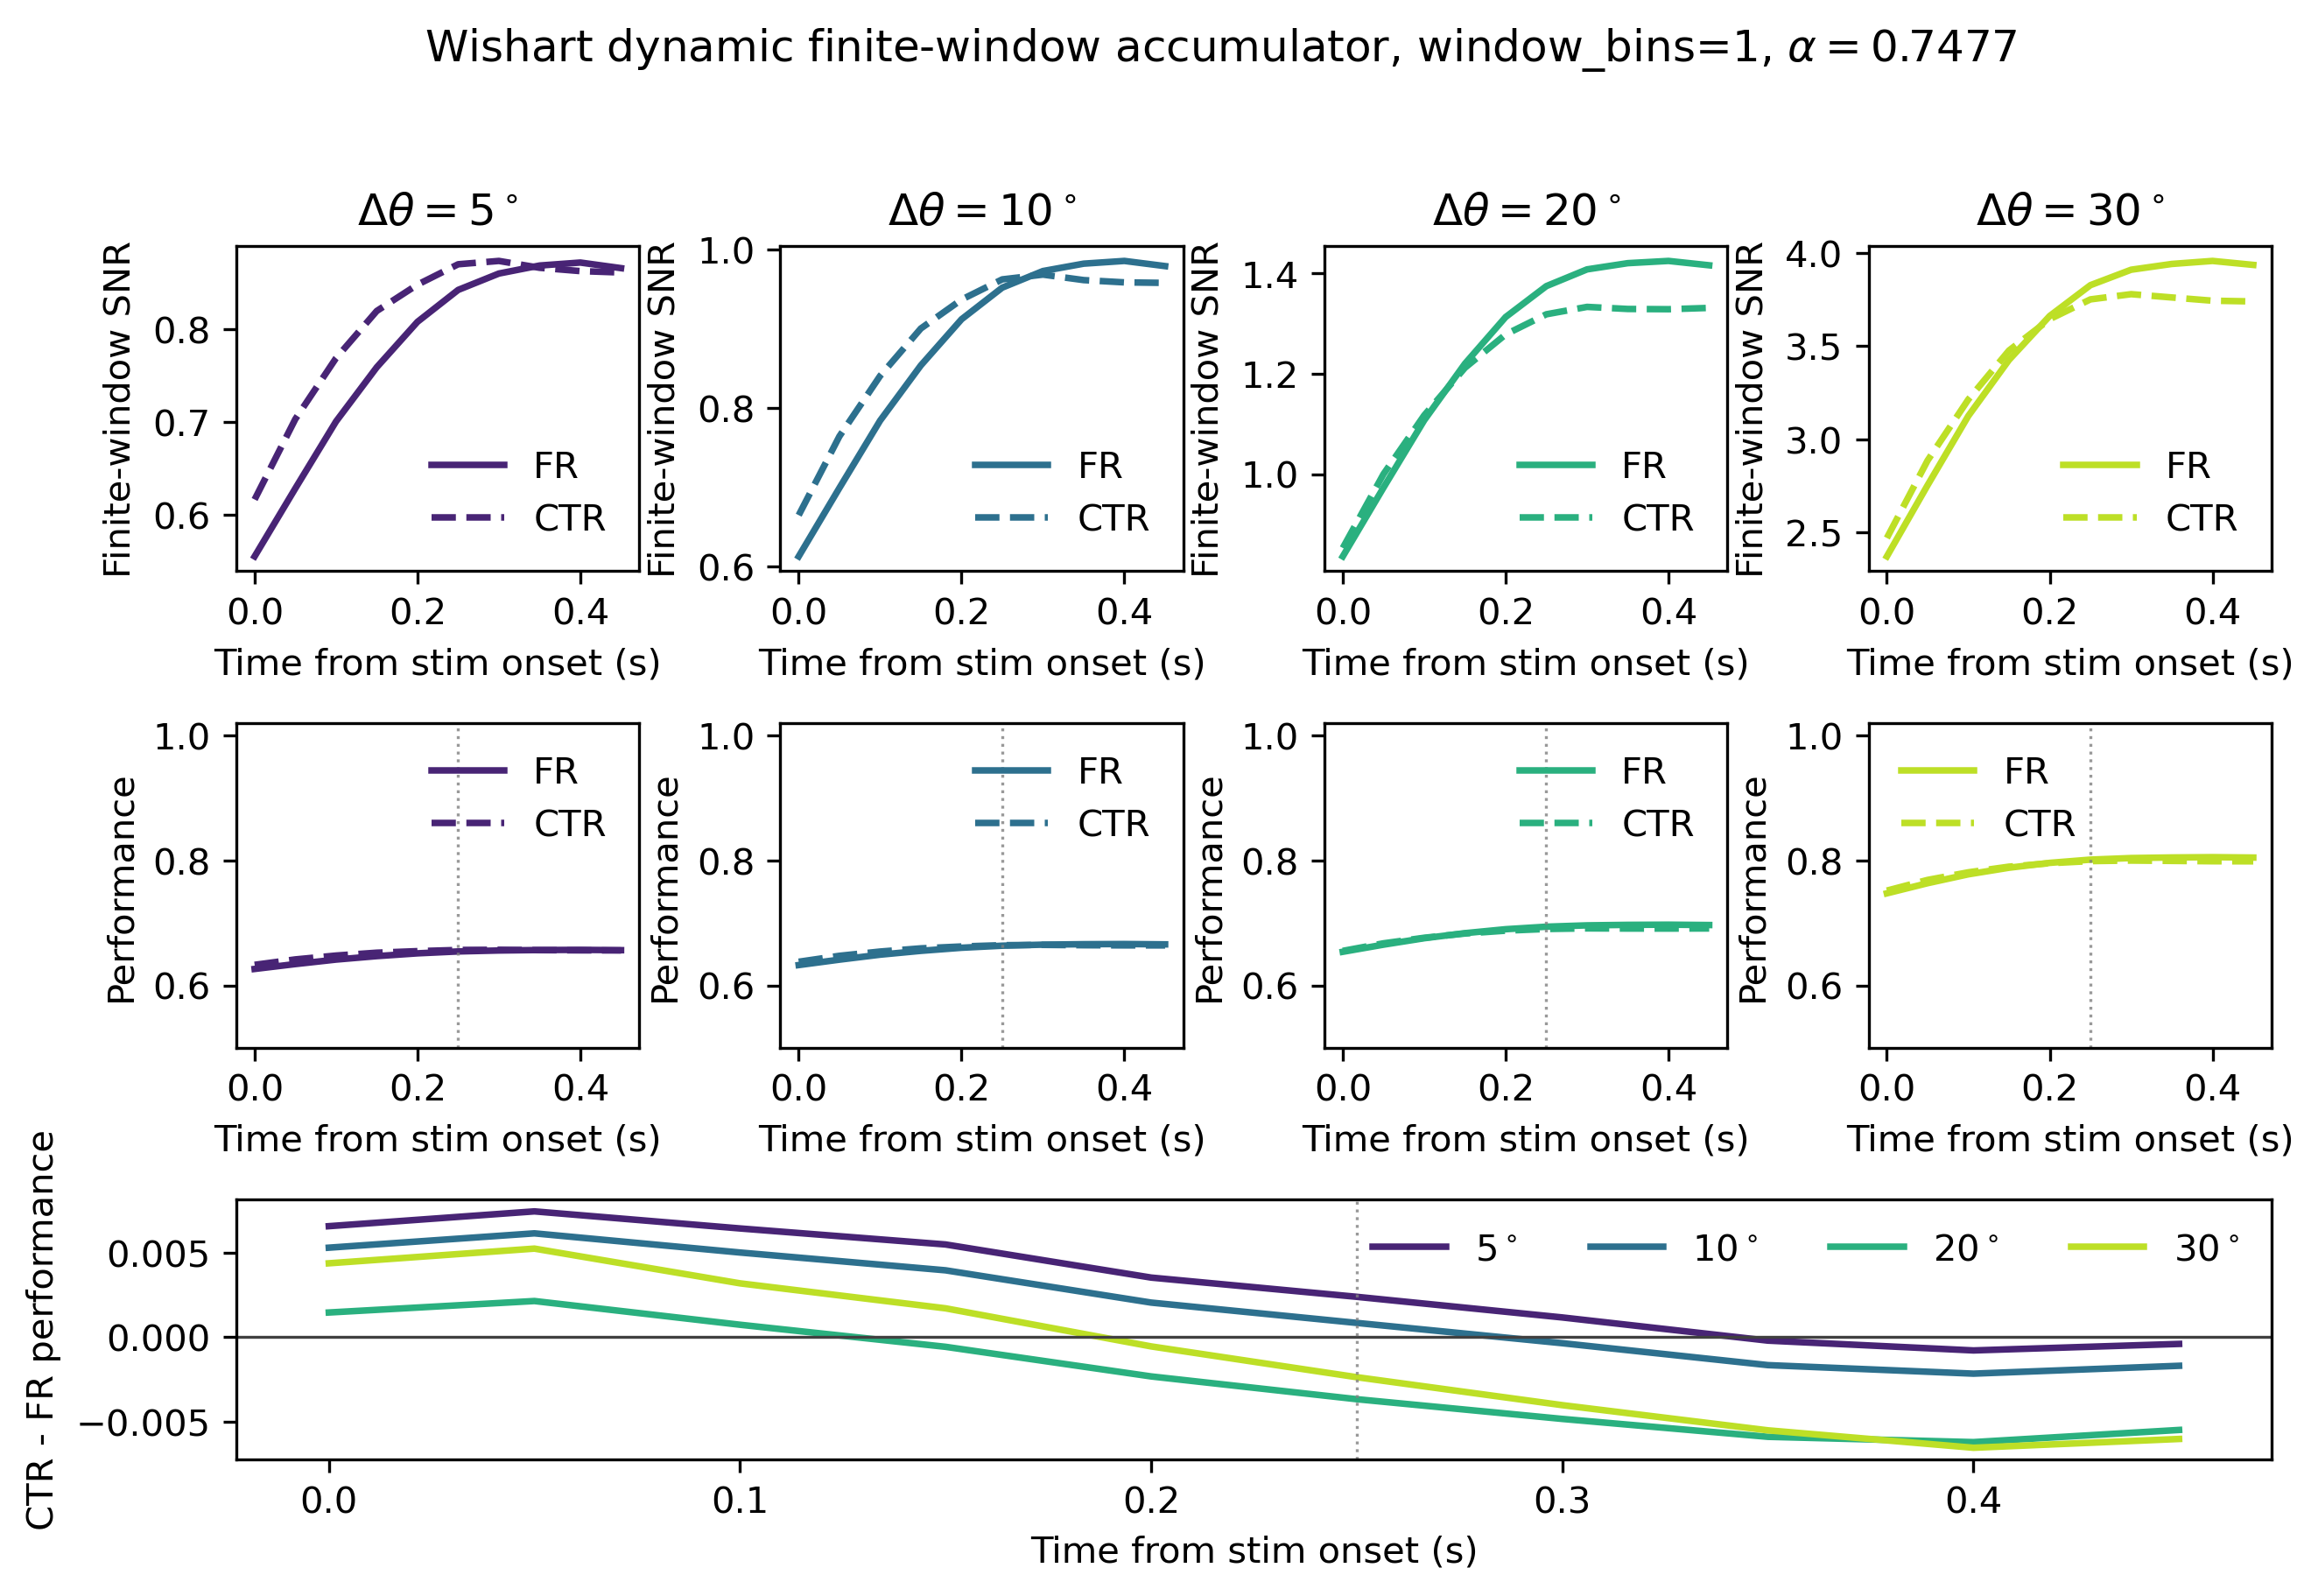

In [6]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import norm

RESULT_DIR = Path("wishart_jun5_dynamic_equal40_sated")

FRAME_RATE = 20
STIM_ONSET_FRAME = 40
MIN_EVAL = 1e-50

# Match the pasted-code behavior: mean over angle origins/SFs after summing modes.
# Use "sum" instead if you want total over all angle origins and SFs.
SPATIAL_AGG = "mean"   # "mean" or "sum"

WINDOW_BINS = 1      # finite accumulator over most recent N dynamic windows
TARGET_GAP = 30.0
TARGET_TIME = 0.25
TARGET_PERF = 0.80
PMAX = None            # or e.g. 0.85
K_MODES = 5
RIDGE = 0#1e-8


def performance_conversion(info, alpha=1.0, pmax=None):
    dprime = np.sqrt(np.maximum(alpha * info, 0))
    p_raw = 0.5 * (1 + erf(dprime / (2 * np.sqrt(2))))

    if pmax is None:
        return p_raw

    return 0.5 + (pmax - 0.5) * (2 * p_raw - 1)


def compute_snr_from_overlaps_eigs(overlaps_small, eigs, min_eval=1e-10):
    overlaps_small = np.asarray(overlaps_small, dtype=float)
    eigs = np.asarray(eigs, dtype=float)

    eigs = np.where(eigs > min_eval, eigs, np.nan)

    # overlaps_small: gap x angle x sf x mode x repeat_axis
    # eigs:          angle x sf x mode x repeat_axis
    if overlaps_small.ndim == eigs.ndim + 1:
        eigs = eigs[None, ...]
    K = K_MODES
    with np.errstate(divide="ignore", invalid="ignore"):
        snr_modes = overlaps_small[..., :K, :] / (eigs[..., :K, :]+RIDGE)

    # Sum over covariance/eigen modes.
    return np.nansum(snr_modes, axis=-2)


def scalar_snr_by_gap(snr_small, n_gaps, agg="mean"):
    flat = snr_small.reshape(n_gaps, -1)

    if agg == "mean":
        return np.nanmean(flat, axis=1)
    if agg == "sum":
        return np.nansum(flat, axis=1)

    raise ValueError("SPATIAL_AGG must be 'mean' or 'sum'")


def finite_window_sum(bin_info, window_bins=2):
    bin_info = np.asarray(bin_info, dtype=float)
    out = np.full_like(bin_info, np.nan, dtype=float)

    for i in range(len(bin_info)):
        start = max(0, i - window_bins + 1)
        out[i] = np.nansum(bin_info[start:i + 1])

    return out


def interp_at_time(time_s, y, t_ref):
    good = np.isfinite(time_s) & np.isfinite(y)
    return np.interp(t_ref, time_s[good], y[good])


def fit_alpha(results, target_gap=30.0, target_time=0.25, target_perf=0.80, window_bins=10, pmax=None):
    r = results[target_gap]

    info_fr = interp_at_time(
        r["time_s"],
        finite_window_sum(r["bin_info_fr"], window_bins),
        target_time,
    )
    info_ctr = interp_at_time(
        r["time_s"],
        finite_window_sum(r["bin_info_ctr"], window_bins),
        target_time,
    )

    mean_info = np.nanmean([info_fr, info_ctr])

    if pmax is None:
        p_raw_target = target_perf
    else:
        p_raw_target = 0.5 + 0.5 * (target_perf - 0.5) / (pmax - 0.5)

    target_dprime = 2 * norm.ppf(p_raw_target)
    alpha = target_dprime**2 / mean_info

    print(f"Fitted alpha = {alpha:.6g}")
    print(f"Target gap {target_gap:g}°, target time {target_time:.3f}s, target perf {target_perf:.3f}")
    print(f"FR info={info_fr:.4f}, CTR info={info_ctr:.4f}, mean={mean_info:.4f}")

    return alpha


# ----------------------------
# Load dynamic Wishart outputs
# ----------------------------

records = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with open(path, "rb") as f:
        d = pickle.load(f)

    group = "FR" if path.name.startswith("FR_") else "CTR"

    gaps = np.asarray(d["small_angle"], dtype=float)
    overlaps_small = np.asarray(d["overlaps_small"], dtype=float)
    eigs = np.asarray(d["eigs_per_condition"], dtype=float)

    snr_small = compute_snr_from_overlaps_eigs(overlaps_small, eigs, min_eval=MIN_EVAL)

    if snr_small.ndim == 3:
        snr_small = snr_small[None, ...]

    value_by_gap = scalar_snr_by_gap(snr_small, len(gaps), agg=SPATIAL_AGG)

    endpoint_frame = int(d["stop"]) - 1
    time_s = (endpoint_frame - STIM_ONSET_FRAME) / FRAME_RATE

    for gap, value in zip(gaps, value_by_gap):
        records.append({
            "group": group,
            "animal": int(d["animal"]),
            "repeat_idx": int(d["repeat_idx"]),
            "start": int(d["start"]),
            "stop": int(d["stop"]),
            "time_s": time_s,
            "gap": float(gap),
            "bin_info": float(value),
        })

df = pd.DataFrame(records)

# Average neuron-subsample repeats within each animal.
animal_df = (
    df.groupby(["group", "animal", "gap", "start", "stop", "time_s"], as_index=False)
      ["bin_info"].mean()
)

group_df = (
    animal_df.groupby(["group", "gap", "time_s"], as_index=False)
    .agg(bin_info=("bin_info", "mean"))
)

results = {}

for gap in sorted(group_df["gap"].unique()):
    fr = group_df[(group_df["gap"] == gap) & (group_df["group"] == "FR")].sort_values("time_s")
    ctr = group_df[(group_df["gap"] == gap) & (group_df["group"] == "CTR")].sort_values("time_s")

    time_s = fr["time_s"].to_numpy()
    bin_info_fr = fr["bin_info"].to_numpy()
    bin_info_ctr = np.interp(time_s, ctr["time_s"].to_numpy(), ctr["bin_info"].to_numpy())

    results[float(gap)] = {
        "time_s": time_s,
        "bin_info_fr": bin_info_fr,
        "bin_info_ctr": bin_info_ctr,
    }

print(f"Loaded {len(df)} gap-level records from {len(list(RESULT_DIR.glob('*_overlaps_eigs.pkl')))} files")
print("Gaps:", sorted(results))


# ----------------------------
# Plot finite-window accumulator
# ----------------------------

alpha = fit_alpha(
    results,
    target_gap=TARGET_GAP,
    target_time=TARGET_TIME,
    target_perf=TARGET_PERF,
    window_bins=WINDOW_BINS,
    pmax=PMAX,
)

gaps = sorted(results)
colors = dict(zip(gaps, plt.cm.viridis(np.linspace(0.1, 0.9, len(gaps)))))

fig = plt.figure(figsize=(2.5 * len(gaps), 6.0), dpi=300)
gs = fig.add_gridspec(3, len(gaps), height_ratios=(1.0, 1.0, 0.8), hspace=0.5, wspace=0.35)

info_axes = [fig.add_subplot(gs[0, i]) for i in range(len(gaps))]
perf_axes = [fig.add_subplot(gs[1, i]) for i in range(len(gaps))]
diff_ax = fig.add_subplot(gs[2, :])

for info_ax, perf_ax, gap in zip(info_axes, perf_axes, gaps):
    r = results[gap]
    color = colors[gap]

    fw_info_fr = finite_window_sum(r["bin_info_fr"], WINDOW_BINS)
    fw_info_ctr = finite_window_sum(r["bin_info_ctr"], WINDOW_BINS)

    fw_perf_fr = performance_conversion(fw_info_fr, alpha=alpha, pmax=PMAX)
    fw_perf_ctr = performance_conversion(fw_info_ctr, alpha=alpha, pmax=PMAX)

    info_ax.plot(r["time_s"], fw_info_fr, color=color, lw=1.8, label="FR")
    info_ax.plot(r["time_s"], fw_info_ctr, color=color, lw=1.8, ls="--", label="CTR")
    info_ax.set_title(rf"$\Delta\theta={gap:g}^\circ$")
    info_ax.set_xlabel("Time from stim onset (s)")
    info_ax.set_ylabel("Finite-window SNR")
    info_ax.legend(frameon=False)

    perf_ax.plot(r["time_s"], fw_perf_fr, color=color, lw=1.8, label="FR")
    perf_ax.plot(r["time_s"], fw_perf_ctr, color=color, lw=1.8, ls="--", label="CTR")
    perf_ax.axvline(TARGET_TIME, color="0.5", lw=0.8, ls=":", alpha=0.8)
    perf_ax.set_xlabel("Time from stim onset (s)")
    perf_ax.set_ylabel("Performance")
    perf_ax.set_ylim(0.5, 1.02)
    perf_ax.legend(frameon=False)

    diff_ax.plot(
        r["time_s"],
        fw_perf_ctr - fw_perf_fr,
        color=color,
        lw=1.8,
        label=rf"${gap:g}^\circ$",
    )

diff_ax.axhline(0, color="0.25", lw=0.8)
diff_ax.axvline(TARGET_TIME, color="0.5", lw=0.8, ls=":", alpha=0.8)
diff_ax.set_xlabel("Time from stim onset (s)")
diff_ax.set_ylabel("CTR - FR performance")
diff_ax.legend(frameon=False, ncol=len(gaps))

fig.suptitle(
    rf"Wishart dynamic finite-window accumulator, window_bins={WINDOW_BINS}, "
    rf"$\alpha={alpha:.4g}$",
    y=1.02,
)
plt.show()


Loaded 5600 gap-level records from 1400 files
Gaps: [5.0, 10.0, 20.0, 30.0]
Fitted alpha = 0.555645
Target gap 30°, target time 0.300s, target perf 0.800
Memory tau = 0.150s
FR info=5.1713, CTR info=5.0270, mean=5.0991


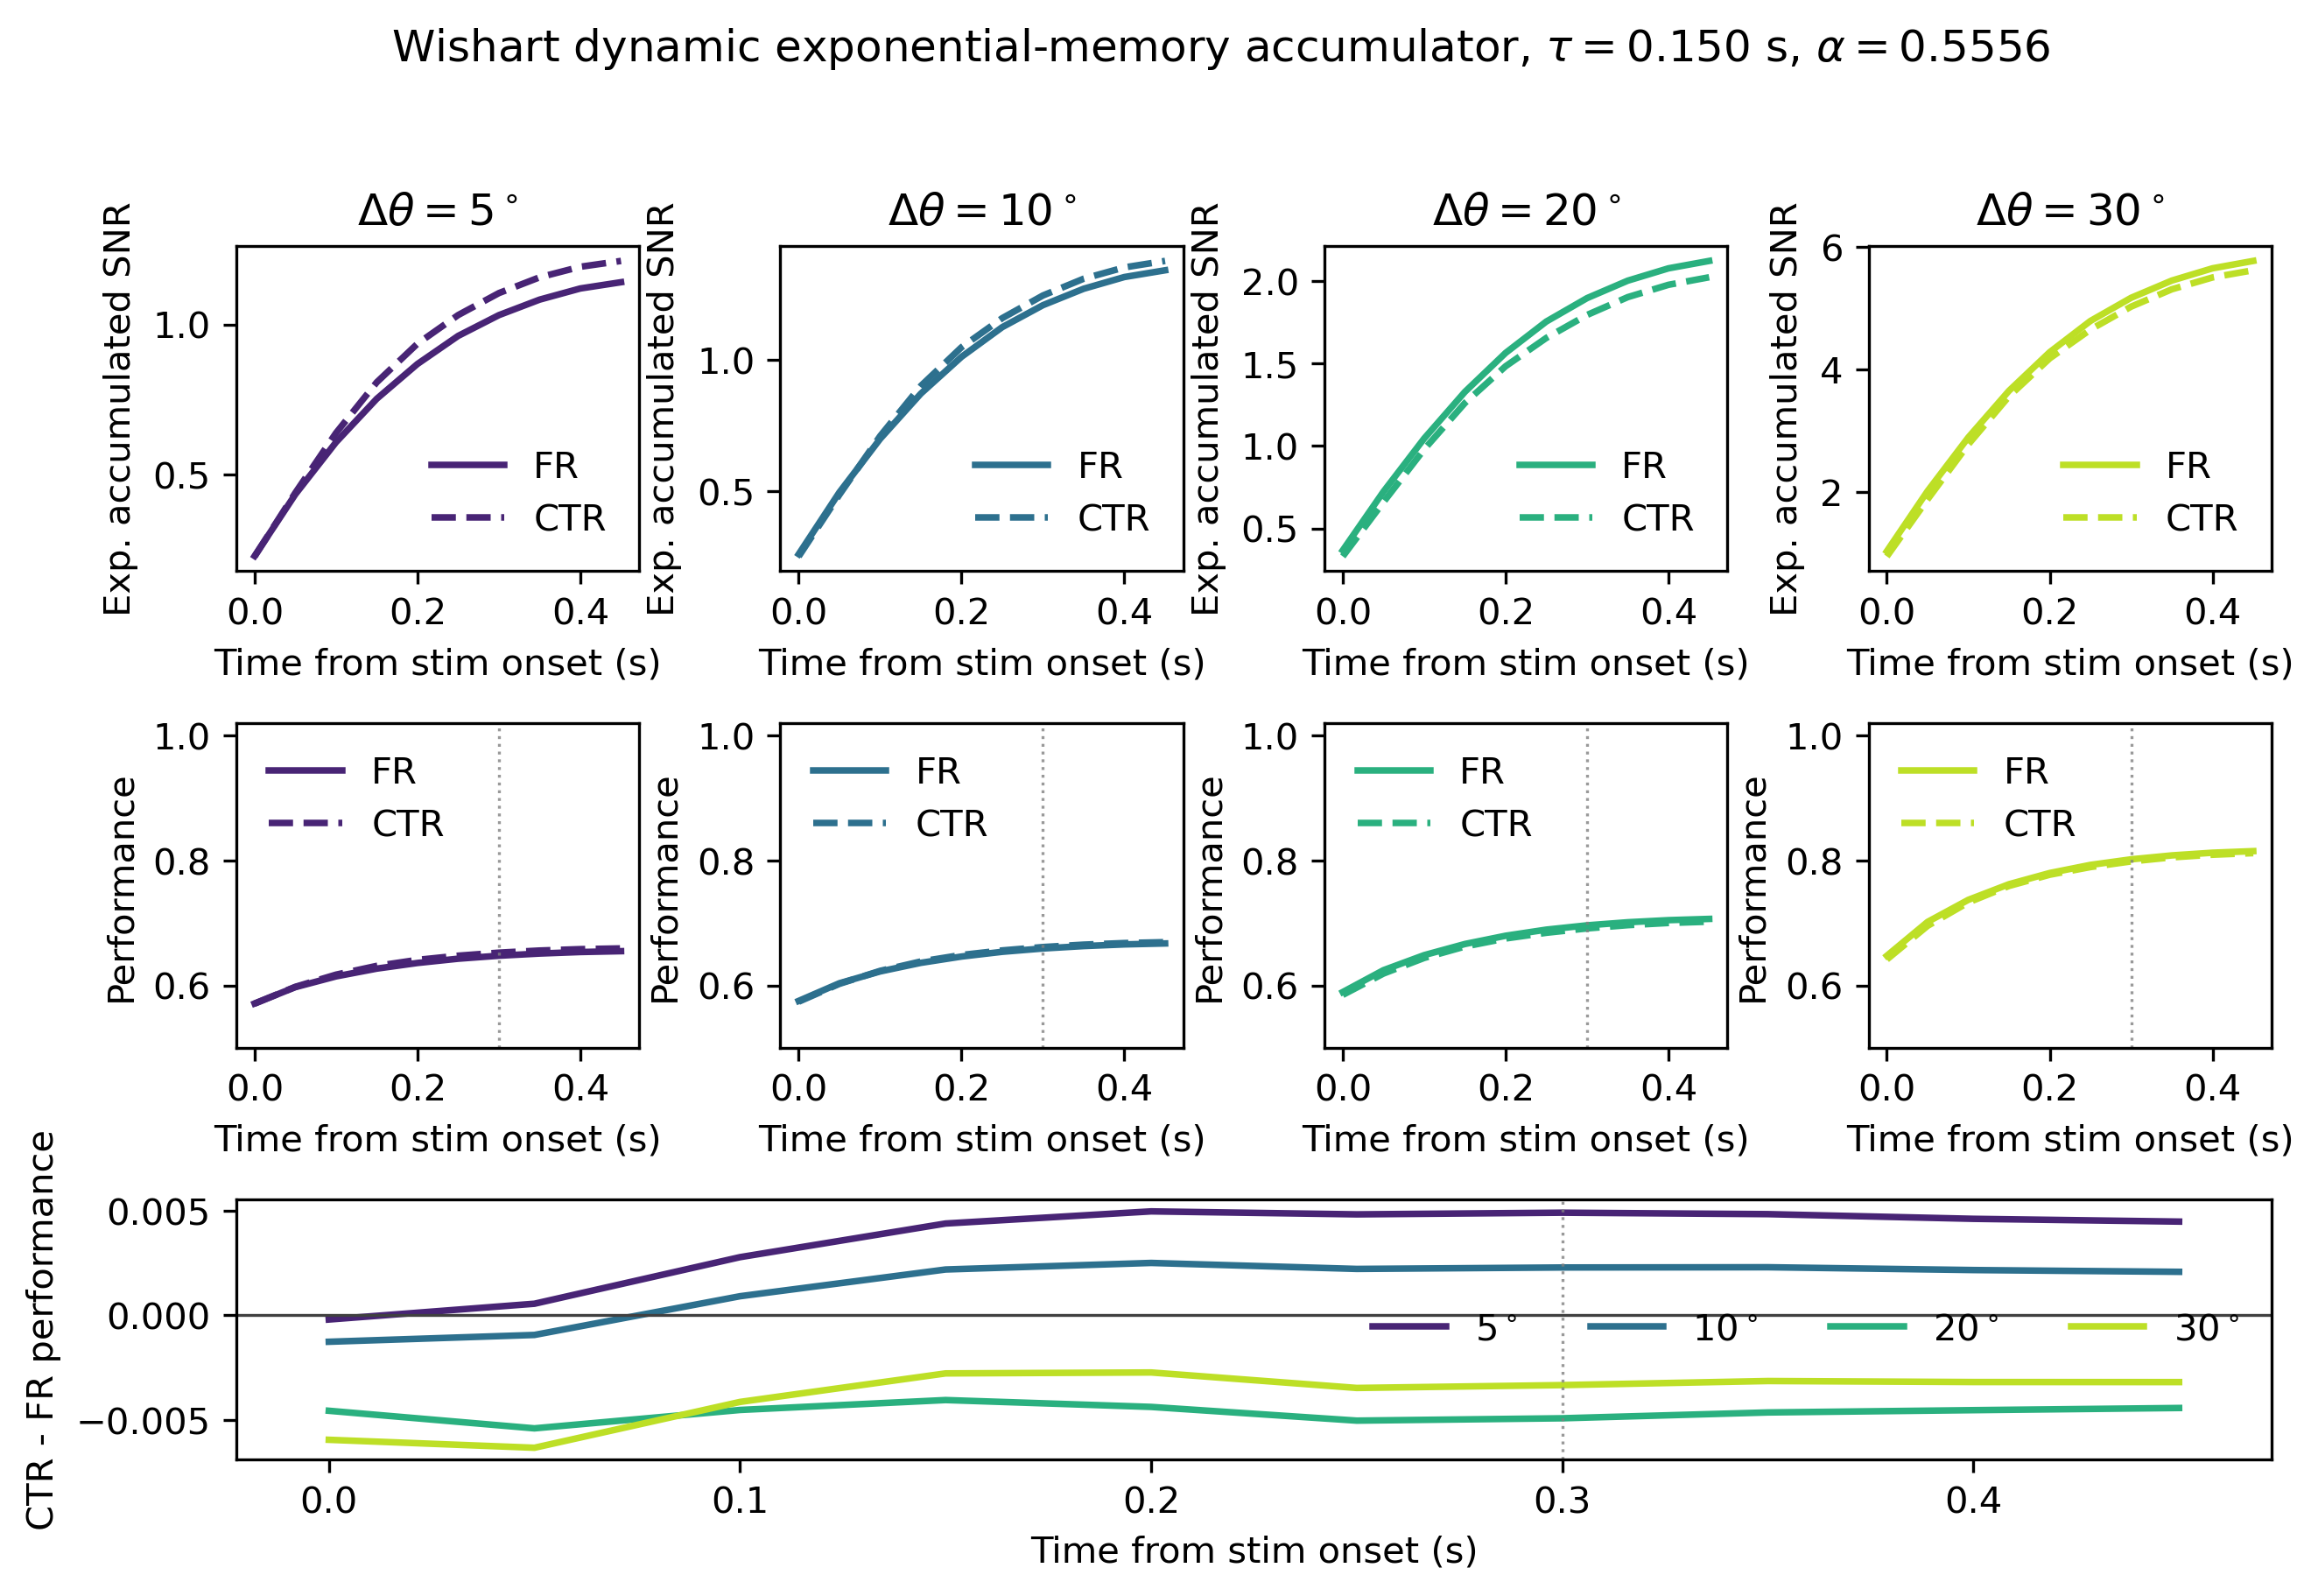

In [7]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erf
from scipy.stats import norm

RESULT_DIR = Path("wishart_jun5_dynamic_equal40_sated")

FRAME_RATE = 20
STIM_ONSET_FRAME = 40
MIN_EVAL = 1e-50

# Match the pasted-code behavior: mean over angle origins/SFs after summing modes.
# Use "sum" if you want total over all angle origins and SFs.
SPATIAL_AGG = "mean"   # "mean" or "sum"

# Exponential memory timescale
MEMORY_TAU = 0.15   # seconds; try 0.10, 0.15, 0.25, 0.50

TARGET_GAP = 30.0
TARGET_TIME = 0.3
TARGET_PERF = 0.80
PMAX = None            # or e.g. 0.85
K_MODES = 2
RIDGE = 0              # or e.g. 1e-8


def performance_conversion(info, alpha=1.0, pmax=None):
    dprime = np.sqrt(np.maximum(alpha * info, 0))
    p_raw = 0.5 * (1 + erf(dprime / (2 * np.sqrt(2))))

    if pmax is None:
        return p_raw

    return 0.5 + (pmax - 0.5) * (2 * p_raw - 1)


def compute_snr_from_overlaps_eigs(overlaps_small, eigs, min_eval=1e-10):
    overlaps_small = np.asarray(overlaps_small, dtype=float)
    eigs = np.asarray(eigs, dtype=float)

    eigs = np.where(eigs > min_eval, eigs, np.nan)

    # overlaps_small: gap x angle x sf x mode x repeat_axis
    # eigs:          angle x sf x mode x repeat_axis
    if overlaps_small.ndim == eigs.ndim + 1:
        eigs = eigs[None, ...]

    K = K_MODES

    with np.errstate(divide="ignore", invalid="ignore"):
        snr_modes = overlaps_small[..., :K, :] / (eigs[..., :K, :] + RIDGE)

    # Sum over covariance/eigen modes.
    return np.nansum(snr_modes, axis=-2)


def scalar_snr_by_gap(snr_small, n_gaps, agg="mean"):
    flat = snr_small.reshape(n_gaps, -1)

    if agg == "mean":
        return np.nanmean(flat, axis=1)

    if agg == "sum":
        return np.nansum(flat, axis=1)

    raise ValueError("SPATIAL_AGG must be 'mean' or 'sum'")


def exponential_memory_sum(bin_info, time_s, tau=0.15, include_dt=False):
    """
    Exponential-memory accumulator:

        I(T) = sum_{t <= T} SNR(t) exp(-(T - t) / tau)

    If include_dt=True, this approximates the continuous-time integral:

        I(T) = integral_0^T dt SNR(t) exp(-(T - t) / tau)

    For comparison with your old finite_window_sum, use include_dt=False,
    because alpha is fitted afterwards anyway.
    """
    bin_info = np.asarray(bin_info, dtype=float)
    time_s = np.asarray(time_s, dtype=float)

    out = np.full_like(bin_info, np.nan, dtype=float)

    if len(bin_info) == 0:
        return out

    # Local time-bin widths, only used if include_dt=True.
    if include_dt:
        diffs = np.diff(time_s)
        good_diffs = diffs[np.isfinite(diffs) & (diffs > 0)]

        if len(good_diffs) > 0:
            default_dt = np.nanmedian(good_diffs)
        else:
            default_dt = 1.0

        dt = np.full_like(time_s, default_dt, dtype=float)
        dt[1:] = np.where(np.isfinite(diffs) & (diffs > 0), diffs, default_dt)
    else:
        dt = np.ones_like(time_s, dtype=float)

    for i in range(len(bin_info)):
        if not np.isfinite(time_s[i]):
            continue

        past = np.arange(i + 1)

        good = (
            np.isfinite(time_s[past])
            & np.isfinite(bin_info[past])
            & (time_s[past] <= time_s[i])
        )

        if not np.any(good):
            continue

        delta_t = time_s[i] - time_s[past][good]
        weights = np.exp(-delta_t / tau)

        out[i] = np.sum(bin_info[past][good] * weights * dt[past][good])

    return out


def interp_at_time(time_s, y, t_ref):
    good = np.isfinite(time_s) & np.isfinite(y)
    return np.interp(t_ref, time_s[good], y[good])


def fit_alpha(
    results,
    target_gap=30.0,
    target_time=0.25,
    target_perf=0.80,
    tau=0.15,
    pmax=None,
):
    r = results[target_gap]

    info_fr = interp_at_time(
        r["time_s"],
        exponential_memory_sum(
            r["bin_info_fr"],
            r["time_s"],
            tau=tau,
            include_dt=False,
        ),
        target_time,
    )

    info_ctr = interp_at_time(
        r["time_s"],
        exponential_memory_sum(
            r["bin_info_ctr"],
            r["time_s"],
            tau=tau,
            include_dt=False,
        ),
        target_time,
    )

    mean_info = np.nanmean([info_fr, info_ctr])

    if pmax is None:
        p_raw_target = target_perf
    else:
        p_raw_target = 0.5 + 0.5 * (target_perf - 0.5) / (pmax - 0.5)

    target_dprime = 2 * norm.ppf(p_raw_target)
    alpha = target_dprime**2 / mean_info

    print(f"Fitted alpha = {alpha:.6g}")
    print(f"Target gap {target_gap:g}°, target time {target_time:.3f}s, target perf {target_perf:.3f}")
    print(f"Memory tau = {tau:.3f}s")
    print(f"FR info={info_fr:.4f}, CTR info={info_ctr:.4f}, mean={mean_info:.4f}")

    return alpha


# ----------------------------
# Load dynamic Wishart outputs
# ----------------------------

records = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with open(path, "rb") as f:
        d = pickle.load(f)

    group = "FR" if path.name.startswith("FR_") else "CTR"

    gaps = np.asarray(d["small_angle"], dtype=float)
    overlaps_small = np.asarray(d["overlaps_small"], dtype=float)
    eigs = np.asarray(d["eigs_per_condition"], dtype=float)

    snr_small = compute_snr_from_overlaps_eigs(
        overlaps_small,
        eigs,
        min_eval=MIN_EVAL,
    )

    if snr_small.ndim == 3:
        snr_small = snr_small[None, ...]

    value_by_gap = scalar_snr_by_gap(
        snr_small,
        len(gaps),
        agg=SPATIAL_AGG,
    )

    endpoint_frame = int(d["stop"]) - 1
    time_s = (endpoint_frame - STIM_ONSET_FRAME) / FRAME_RATE

    for gap, value in zip(gaps, value_by_gap):
        records.append({
            "group": group,
            "animal": int(d["animal"]),
            "repeat_idx": int(d["repeat_idx"]),
            "start": int(d["start"]),
            "stop": int(d["stop"]),
            "time_s": time_s,
            "gap": float(gap),
            "bin_info": float(value),
        })

df = pd.DataFrame(records)

# Average neuron-subsample repeats within each animal.
animal_df = (
    df.groupby(
        ["group", "animal", "gap", "start", "stop", "time_s"],
        as_index=False,
    )["bin_info"].mean()
)

group_df = (
    animal_df.groupby(["group", "gap", "time_s"], as_index=False)
    .agg(bin_info=("bin_info", "mean"))
)

results = {}

for gap in sorted(group_df["gap"].unique()):
    fr = (
        group_df[
            (group_df["gap"] == gap)
            & (group_df["group"] == "FR")
        ]
        .sort_values("time_s")
    )

    ctr = (
        group_df[
            (group_df["gap"] == gap)
            & (group_df["group"] == "CTR")
        ]
        .sort_values("time_s")
    )

    time_s = fr["time_s"].to_numpy()
    bin_info_fr = fr["bin_info"].to_numpy()

    bin_info_ctr = np.interp(
        time_s,
        ctr["time_s"].to_numpy(),
        ctr["bin_info"].to_numpy(),
    )

    results[float(gap)] = {
        "time_s": time_s,
        "bin_info_fr": bin_info_fr,
        "bin_info_ctr": bin_info_ctr,
    }

print(
    f"Loaded {len(df)} gap-level records from "
    f"{len(list(RESULT_DIR.glob('*_overlaps_eigs.pkl')))} files"
)
print("Gaps:", sorted(results))


# ----------------------------
# Plot exponential-memory accumulator
# ----------------------------

alpha = fit_alpha(
    results,
    target_gap=TARGET_GAP,
    target_time=TARGET_TIME,
    target_perf=TARGET_PERF,
    tau=MEMORY_TAU,
    pmax=PMAX,
)

gaps = sorted(results)
colors = dict(zip(gaps, plt.cm.viridis(np.linspace(0.1, 0.9, len(gaps)))))

fig = plt.figure(figsize=(2.5 * len(gaps), 6.0), dpi=300)
gs = fig.add_gridspec(
    3,
    len(gaps),
    height_ratios=(1.0, 1.0, 0.8),
    hspace=0.5,
    wspace=0.35,
)

info_axes = [fig.add_subplot(gs[0, i]) for i in range(len(gaps))]
perf_axes = [fig.add_subplot(gs[1, i]) for i in range(len(gaps))]
diff_ax = fig.add_subplot(gs[2, :])

for info_ax, perf_ax, gap in zip(info_axes, perf_axes, gaps):
    r = results[gap]
    color = colors[gap]

    mem_info_fr = exponential_memory_sum(
        r["bin_info_fr"],
        r["time_s"],
        tau=MEMORY_TAU,
        include_dt=False,
    )

    mem_info_ctr = exponential_memory_sum(
        r["bin_info_ctr"],
        r["time_s"],
        tau=MEMORY_TAU,
        include_dt=False,
    )

    mem_perf_fr = performance_conversion(
        mem_info_fr,
        alpha=alpha,
        pmax=PMAX,
    )

    mem_perf_ctr = performance_conversion(
        mem_info_ctr,
        alpha=alpha,
        pmax=PMAX,
    )

    info_ax.plot(
        r["time_s"],
        mem_info_fr,
        color=color,
        lw=1.8,
        label="FR",
    )

    info_ax.plot(
        r["time_s"],
        mem_info_ctr,
        color=color,
        lw=1.8,
        ls="--",
        label="CTR",
    )

    info_ax.set_title(rf"$\Delta\theta={gap:g}^\circ$")
    info_ax.set_xlabel("Time from stim onset (s)")
    info_ax.set_ylabel("Exp. accumulated SNR")
    info_ax.legend(frameon=False)

    perf_ax.plot(
        r["time_s"],
        mem_perf_fr,
        color=color,
        lw=1.8,
        label="FR",
    )

    perf_ax.plot(
        r["time_s"],
        mem_perf_ctr,
        color=color,
        lw=1.8,
        ls="--",
        label="CTR",
    )

    perf_ax.axvline(
        TARGET_TIME,
        color="0.5",
        lw=0.8,
        ls=":",
        alpha=0.8,
    )

    perf_ax.set_xlabel("Time from stim onset (s)")
    perf_ax.set_ylabel("Performance")
    perf_ax.set_ylim(0.5, 1.02)
    perf_ax.legend(frameon=False)

    diff_ax.plot(
        r["time_s"],
        mem_perf_ctr - mem_perf_fr,
        color=color,
        lw=1.8,
        label=rf"${gap:g}^\circ$",
    )

diff_ax.axhline(0, color="0.25", lw=0.8)
diff_ax.axvline(TARGET_TIME, color="0.5", lw=0.8, ls=":", alpha=0.8)
diff_ax.set_xlabel("Time from stim onset (s)")
diff_ax.set_ylabel("CTR - FR performance")
diff_ax.legend(frameon=False, ncol=len(gaps))

fig.suptitle(
    rf"Wishart dynamic exponential-memory accumulator, "
    rf"$\tau={MEMORY_TAU:.3f}$ s, "
    rf"$\alpha={alpha:.4g}$",
    y=1.02,
)

plt.show()

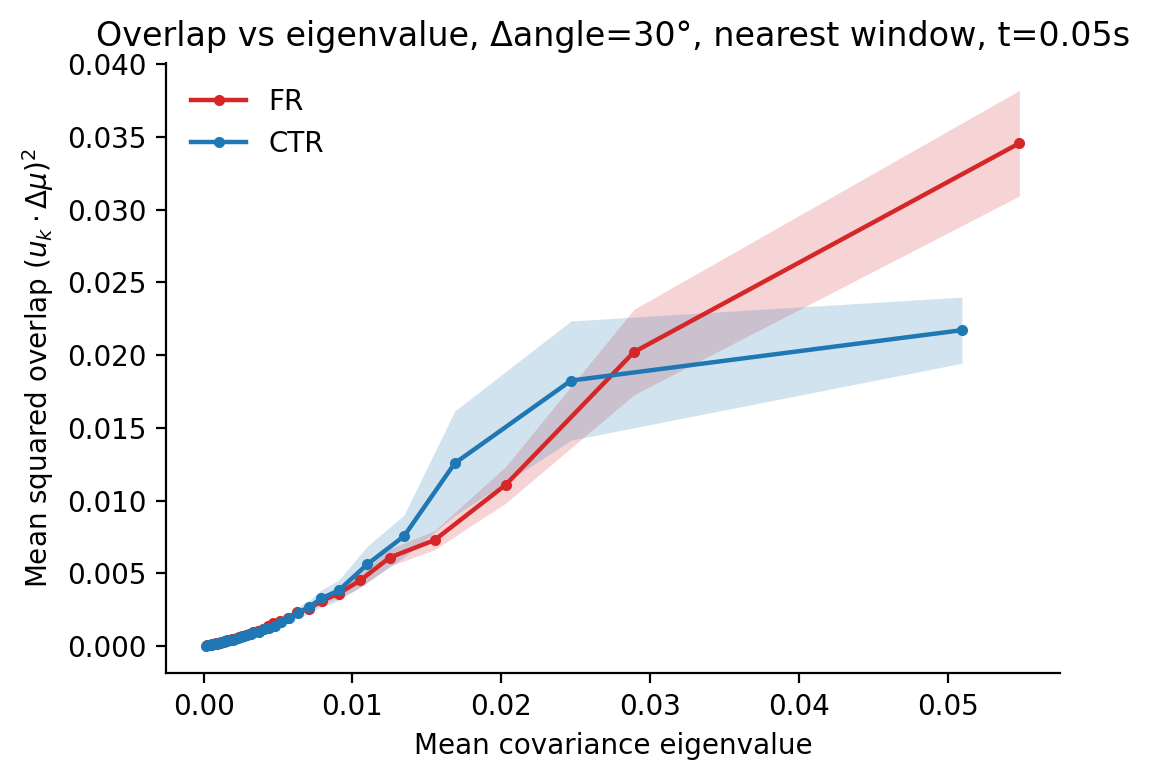

In [3]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = Path("wishart_jun5_dynamic_equal40_sated")
# RESULT_DIR = Path("wishart_jun8_static_equal40_sated")

# RESULT_DIR = Path("wishart_jun3_dynamic_equal40_sated")
# RESULT_DIR = Path("wishart_raw_mu_gp_interp_jun2_static_equal40_sated")
TIME_SELECT = "0.05"   # "final", "all", or a number like 0.25
SPATIAL_AGG = "mean"    # "mean" or "sum" over angle origins/SFs
LOG_Y = False
ANGLE_SELECT = 30.0    # plot only this angle gap in degrees

records = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with open(path, "rb") as f:
        d = pickle.load(f)

    group = "FR" if path.name.startswith("FR_") else "CTR"
    gaps = np.asarray(d["small_angle"], dtype=float)

    overlaps_small = np.asarray(d["overlaps_small"], dtype=float)
    # shape: gap x angle_origin x sf x mode x repeat_axis
    eigs = np.asarray(d["eigs_per_condition"], dtype=float)
    # shape: angle_origin x sf x mode x repeat_axis

    if overlaps_small.ndim == 4:
        overlaps_small = overlaps_small[None, ...]
    if eigs.ndim == 3:
        eigs = eigs[..., None]

    eigenvalue_by_mode = np.nanmean(eigs, axis=(0, 1, 3))

    time_s = (int(d["stop"]) - 1 - 40) / 20

    for gi, gap in enumerate(gaps):
        if not np.isclose(gap, ANGLE_SELECT):
            continue

        overlap_gap = overlaps_small[gi]

        if SPATIAL_AGG == "mean":
            overlap_by_mode = np.nanmean(overlap_gap, axis=(0, 1, 3))
        elif SPATIAL_AGG == "sum":
            overlap_by_mode = np.nansum(overlap_gap, axis=(0, 1, 3))
        else:
            raise ValueError("SPATIAL_AGG must be 'mean' or 'sum'")

        for mode_idx, (overlap, eigenvalue) in enumerate(zip(overlap_by_mode, eigenvalue_by_mode)):
            records.append({
                "group": group,
                "animal": int(d["animal"]),
                "repeat_idx": int(d["repeat_idx"]),
                "time_s": time_s,
                "gap": float(gap),
                "mode": mode_idx + 1,
                "overlap": float(overlap),
                "eigenvalue": float(eigenvalue),
            })

df = pd.DataFrame(records)
if df.empty:
    raise ValueError(f"No records found for ANGLE_SELECT={ANGLE_SELECT:g} degrees")

if TIME_SELECT == "final":
    time_to_plot = df["time_s"].max()
    df_plot = df[np.isclose(df["time_s"], time_to_plot)].copy()
    title_time = f"final window, t={time_to_plot:.2f}s"
elif TIME_SELECT == "all":
    df_plot = df.copy()
    title_time = "all dynamic windows averaged"
else:
    time_to_plot = float(TIME_SELECT)
    nearest = df["time_s"].iloc[np.argmin(np.abs(df["time_s"].to_numpy() - time_to_plot))]
    df_plot = df[np.isclose(df["time_s"], nearest)].copy()
    title_time = f"nearest window, t={nearest:.2f}s"

# Average neuron-subsample repeats within animal first.
animal_df = (
    df_plot.groupby(["group", "animal", "gap", "mode"], as_index=False)
    .agg(
        overlap=("overlap", "mean"),
        eigenvalue=("eigenvalue", "mean"),
    )
)

summary = (
    animal_df.groupby(["group", "gap", "mode"], as_index=False)
    .agg(
        mean_overlap=("overlap", "mean"),
        sem_overlap=("overlap", "sem"),
        mean_eigenvalue=("eigenvalue", "mean"),
        n_animals=("animal", "nunique"),
    )
)

colors = {"FR": "tab:red", "CTR": "tab:blue"}

for gap in sorted(summary["gap"].unique()):
    fig, ax = plt.subplots(figsize=(5.5, 4), dpi=200)

    for group in ["FR", "CTR"]:
        sub = summary[
            (summary["gap"] == gap) &
            (summary["group"] == group)
        ].sort_values("mode")

        x = sub["mean_eigenvalue"].to_numpy()
        y = sub["mean_overlap"].to_numpy()
        sem = sub["sem_overlap"].to_numpy()
        #remove top 5 modes
        y = y[:]
        x = x[:]
        sem = sem[:]

        ax.plot(x, y, marker="o", ms=3, lw=1.6, color=colors[group], label=group)
        ax.fill_between(x, y - sem, y + sem, color=colors[group], alpha=0.2, linewidth=0)

    ax.set_title(f"Overlap vs eigenvalue, Δangle={gap:g}°, {title_time}")
    ax.set_xlabel("Mean covariance eigenvalue")
    ax.set_ylabel(r"Mean squared overlap $(u_k \cdot \Delta\mu)^2$")

    if LOG_Y:
        ax.set_yscale("log")

    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

group  alpha_y_term  beta_sqrt_y_term  x_equal_terms  linear_frac_lowest_x_quartile  linear_frac_highest_x_quartile  quadratic_frac_lowest_x_quartile  quadratic_frac_highest_x_quartile
   FR      0.937625          0.092098       0.018093                       0.900699                        0.588437                          0.099301                           0.411563
  CTR      1.002616          0.090874       0.016473                       0.901703                        0.574242                          0.098297                           0.425758


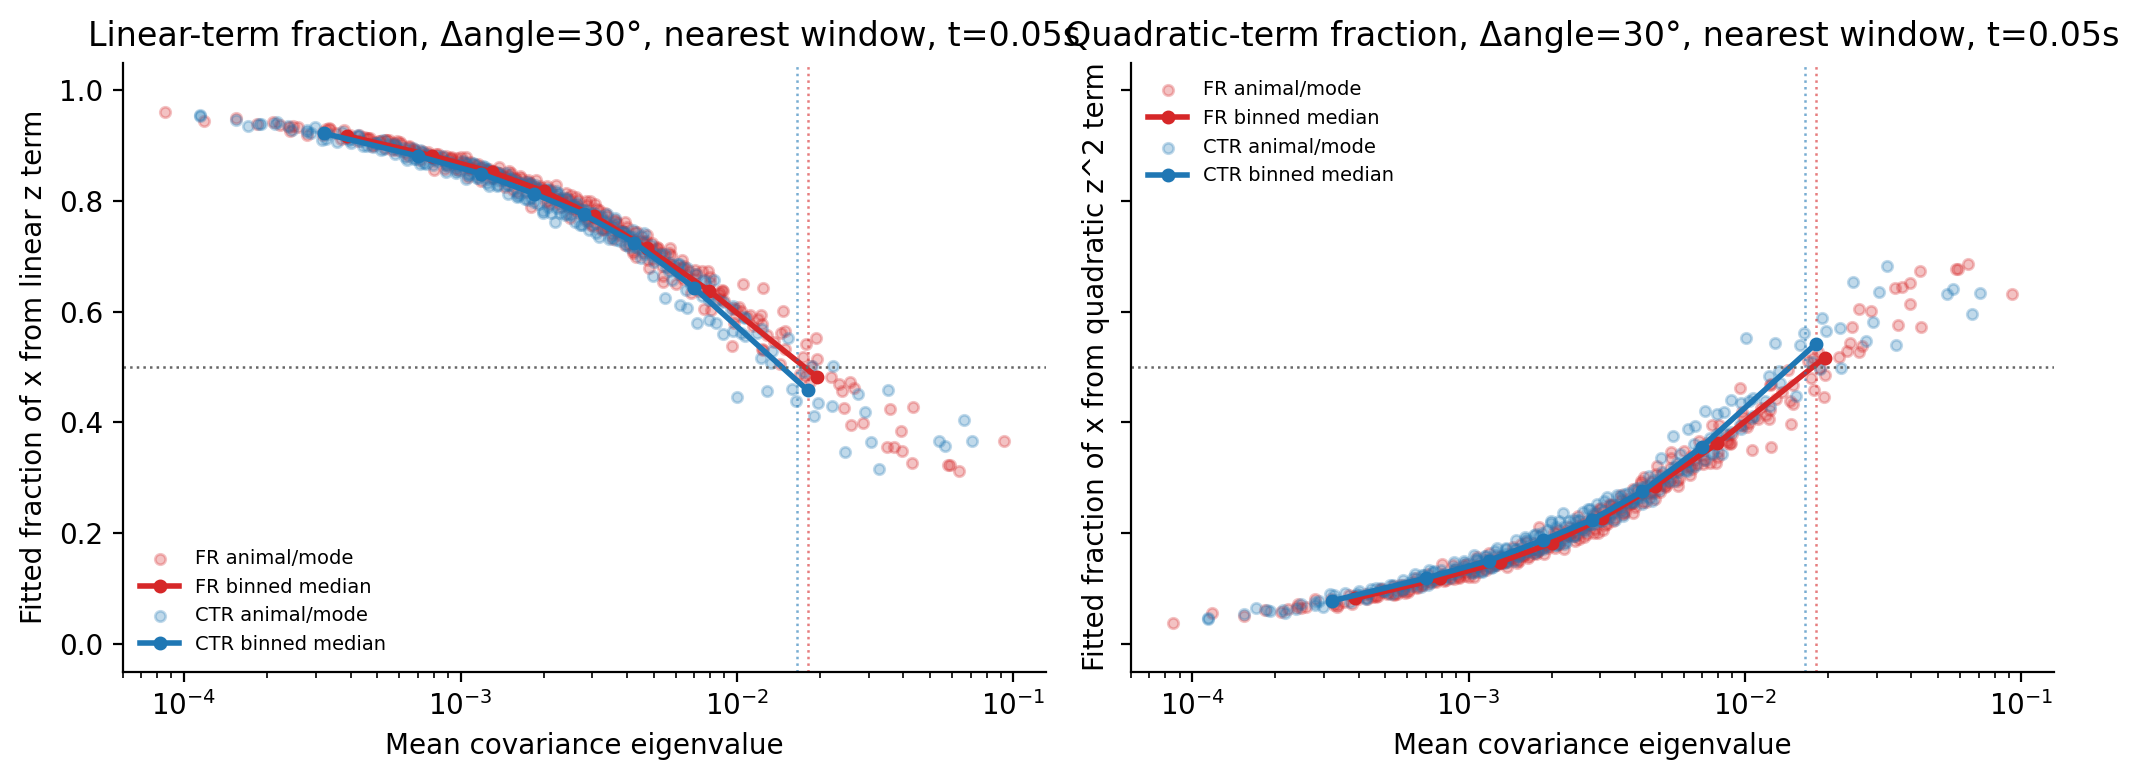

In [4]:
# Diagnostic: linear-vs-quadratic contribution in x
# If y = A*z^2 and x = B*z^2 + C*z, then x = alpha*y + beta*sqrt(y).
diagnostic_df = animal_df.copy()
diagnostic_df = diagnostic_df[
    np.isfinite(diagnostic_df["overlap"]) &
    np.isfinite(diagnostic_df["eigenvalue"]) &
    (diagnostic_df["overlap"] > 0) &
    (diagnostic_df["eigenvalue"] > 0)
].copy()
diagnostic_df["sqrt_overlap"] = np.sqrt(diagnostic_df["overlap"])

rows = []
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), dpi=200, sharey=True)
linear_ax, quadratic_ax = axes

for group in ["FR", "CTR"]:
    sub = diagnostic_df[diagnostic_df["group"] == group].copy()
    if len(sub) < 3:
        continue

    design = sub[["overlap", "sqrt_overlap"]].to_numpy()
    target = sub["eigenvalue"].to_numpy()
    alpha, beta = np.linalg.lstsq(design, target, rcond=None)[0]

    quad_part = alpha * sub["overlap"].to_numpy()
    linear_part = beta * sub["sqrt_overlap"].to_numpy()
    fitted_x = quad_part + linear_part
    sub["linear_fraction"] = linear_part / fitted_x
    sub["quadratic_fraction"] = quad_part / fitted_x

    order = np.argsort(sub["eigenvalue"].to_numpy())
    x_sorted = sub["eigenvalue"].to_numpy()[order]
    frac_sorted = sub["linear_fraction"].to_numpy()[order]

    linear_ax.scatter(
        sub["eigenvalue"],
        sub["linear_fraction"],
        s=14,
        alpha=0.28,
        color=colors[group],
        label=f"{group} animal/mode",
    )
    quadratic_ax.scatter(
        sub["eigenvalue"],
        sub["quadratic_fraction"],
        s=14,
        alpha=0.28,
        color=colors[group],
        label=f"{group} animal/mode",
    )

    n_bins = min(8, max(2, len(sub) // 20))
    bins = pd.qcut(sub["eigenvalue"], q=n_bins, duplicates="drop")
    binned = (
        sub.assign(eigen_bin=bins)
        .groupby("eigen_bin", observed=True, as_index=False)
        .agg(
            x_mid=("eigenvalue", "median"),
            linear_fraction=("linear_fraction", "median"),
            quadratic_fraction=("quadratic_fraction", "median"),
        )
    )
    linear_ax.plot(
        binned["x_mid"],
        binned["linear_fraction"],
        color=colors[group],
        lw=2,
        marker="o",
        ms=4,
        label=f"{group} binned median",
    )
    quadratic_ax.plot(
        binned["x_mid"],
        binned["quadratic_fraction"],
        color=colors[group],
        lw=2,
        marker="o",
        ms=4,
        label=f"{group} binned median",
    )

    x_equal = np.nan
    if alpha > 0 and beta > 0:
        y_equal = (beta / alpha) ** 2
        x_equal = alpha * y_equal + beta * np.sqrt(y_equal)
        linear_ax.axvline(x_equal, color=colors[group], lw=0.9, ls=":", alpha=0.6)
        quadratic_ax.axvline(x_equal, color=colors[group], lw=0.9, ls=":", alpha=0.6)

    low_cut = sub["eigenvalue"].quantile(0.25)
    high_cut = sub["eigenvalue"].quantile(0.75)
    rows.append({
        "group": group,
        "alpha_y_term": alpha,
        "beta_sqrt_y_term": beta,
        "x_equal_terms": x_equal,
        "linear_frac_lowest_x_quartile": sub.loc[sub["eigenvalue"] <= low_cut, "linear_fraction"].median(),
        "linear_frac_highest_x_quartile": sub.loc[sub["eigenvalue"] >= high_cut, "linear_fraction"].median(),
        "quadratic_frac_lowest_x_quartile": sub.loc[sub["eigenvalue"] <= low_cut, "quadratic_fraction"].median(),
        "quadratic_frac_highest_x_quartile": sub.loc[sub["eigenvalue"] >= high_cut, "quadratic_fraction"].median(),
    })

diagnostic_summary = pd.DataFrame(rows)
print(diagnostic_summary.to_string(index=False))

for axis in axes:
    axis.axhline(0.5, color="0.4", lw=0.9, ls=":")
    axis.set_xscale("log")
    axis.set_ylim(-0.05, 1.05)
    axis.set_xlabel("Mean covariance eigenvalue")
    axis.legend(frameon=False, fontsize=7)
    axis.spines[["top", "right"]].set_visible(False)

linear_ax.set_ylabel("Fitted fraction of x from linear z term")
quadratic_ax.set_ylabel("Fitted fraction of x from quadratic z^2 term")
linear_ax.set_title(f"Linear-term fraction, Δangle={ANGLE_SELECT:g}°, {title_time}")
quadratic_ax.set_title(f"Quadratic-term fraction, Δangle={ANGLE_SELECT:g}°, {title_time}")
plt.tight_layout()
plt.show()


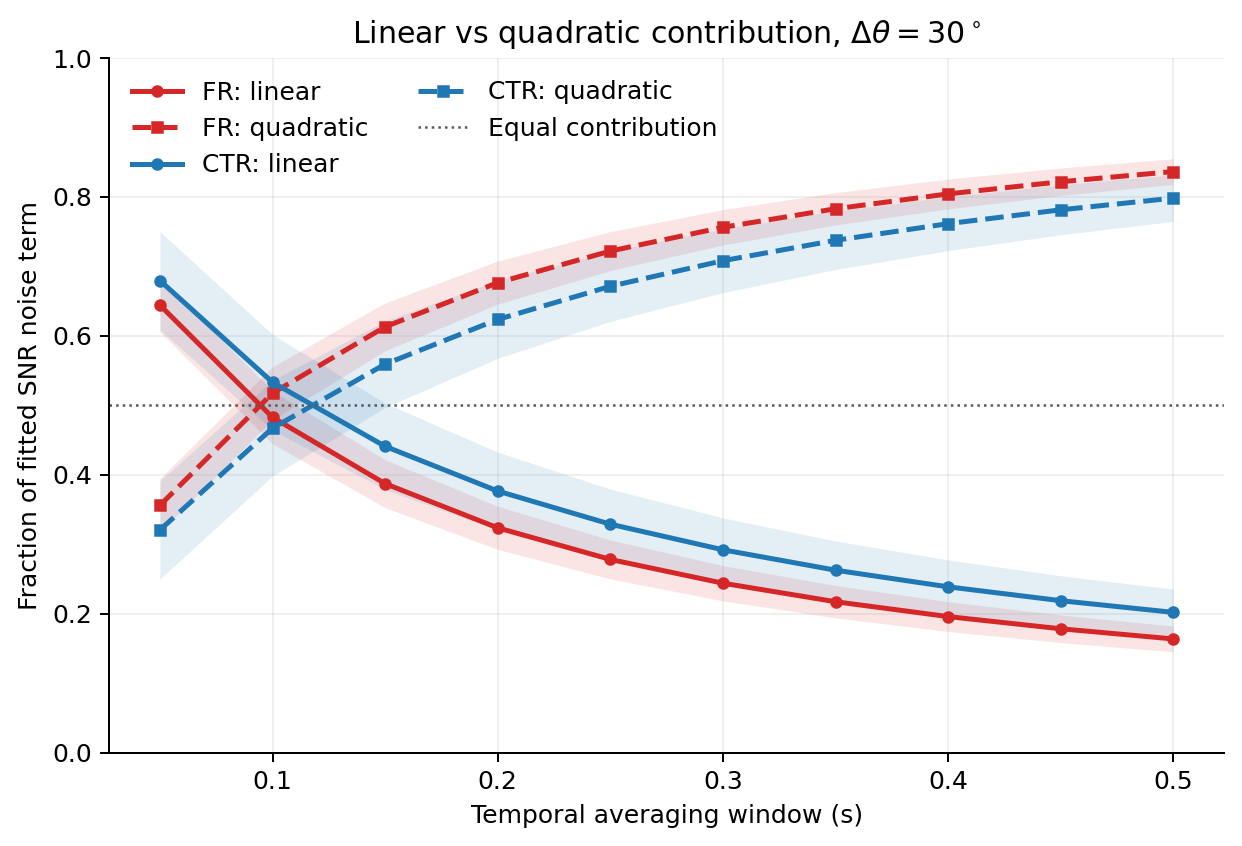

alpha                beta          
           mean       sem      mean       sem
group                                        
CTR    0.599715  0.149948  0.087454  0.011850
FR     0.641060  0.051261  0.088949  0.008215

In [8]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import nnls


RESULT_DIR = Path("wishart_jun3_dynamic_equal40_sated")

TARGET_GAP = 30.0
FRAME_RATE = 20.0
MODE_START = 1        # remove top eigenmode


# ------------------------- Load data -------------------------

rows = []

for path in sorted(RESULT_DIR.glob("*_overlaps_eigs.pkl")):
    with path.open("rb") as f:
        d = pickle.load(f)

    gaps = np.asarray(d["small_angle"], dtype=float)
    gap_idx = np.flatnonzero(np.isclose(gaps, TARGET_GAP))

    if len(gap_idx) != 1:
        continue

    overlaps = np.asarray(d["overlaps_small"], dtype=float)
    eigenvalues = np.asarray(d["eigs_per_condition"], dtype=float)

    if overlaps.ndim == 4:
        overlaps = overlaps[None, ...]
    if eigenvalues.ndim == 3:
        eigenvalues = eigenvalues[..., None]

    # Mean over angle origins, spatial frequencies, and internal repeat axis.
    overlap_by_mode = np.nanmean(
        overlaps[gap_idx[0]],
        axis=(0, 1, 3),
    )
    eigenvalue_by_mode = np.nanmean(
        eigenvalues,
        axis=(0, 1, 3),
    )

    group = "FR" if path.name.startswith("FR_") else "CTR"

    for mode in range(MODE_START, len(overlap_by_mode)):
        rows.append({
            "group": group,
            "animal": int(d["animal"]),
            "repeat": int(d["repeat_idx"]),
            "start": int(d["start"]),
            "mode": mode,
            "overlap": float(overlap_by_mode[mode]),
            "eigenvalue": float(eigenvalue_by_mode[mode]),
        })

df = pd.DataFrame(rows)

# Average neuron-subsample repeats within each animal first.
animal_points = (
    df.groupby(
        ["group", "animal", "start", "mode"],
        as_index=False,
    )[["overlap", "eigenvalue"]]
    .mean()
)

n_available_bins = animal_points["start"].nunique()


# ---------------- Fit model per animal ----------------
#
# One-frame model:
#     eigenvalue = alpha * overlap + beta * sqrt(overlap)
#
# For an n-frame average:
#     quadratic = alpha * overlap
#     linear    = beta * sqrt(overlap) / n

curve_rows = []
fit_rows = []

for (group, animal), sub in animal_points.groupby(["group", "animal"]):
    sub = sub[
        np.isfinite(sub["overlap"])
        & np.isfinite(sub["eigenvalue"])
        & (sub["overlap"] > 0)
        & (sub["eigenvalue"] > 0)
    ]

    y = sub["overlap"].to_numpy()
    x = sub["eigenvalue"].to_numpy()

    # Non-negative fit keeps both variance components interpretable.
    alpha, beta = nnls(
        np.column_stack([y, np.sqrt(y)]),
        x,
    )[0]

    fit_rows.append({
        "group": group,
        "animal": animal,
        "alpha": alpha,
        "beta": beta,
    })

    for n_bins in range(1, n_available_bins + 1):
        quadratic = alpha * y
        linear = beta * np.sqrt(y) / n_bins

        quadratic_total = np.sum(quadratic)
        linear_total = np.sum(linear)
        fitted_total = quadratic_total + linear_total

        curve_rows.append({
            "group": group,
            "animal": animal,
            "bins": n_bins,
            "seconds": n_bins / FRAME_RATE,
            "linear_fraction": linear_total / fitted_total,
            "quadratic_fraction": quadratic_total / fitted_total,
        })

curve_df = pd.DataFrame(curve_rows)
fit_df = pd.DataFrame(fit_rows)


# Mean and SEM across animals.
summary = (
    curve_df.groupby(
        ["group", "bins", "seconds"],
        as_index=False,
    )
    .agg(
        linear_mean=("linear_fraction", "mean"),
        linear_sem=("linear_fraction", "sem"),
        quadratic_mean=("quadratic_fraction", "mean"),
        quadratic_sem=("quadratic_fraction", "sem"),
        n_animals=("animal", "nunique"),
    )
)


# ---------------------------- Plot ----------------------------

colors = {
    "FR": "tab:red",
    "CTR": "tab:blue",
}

fig, ax = plt.subplots(figsize=(7, 4.8), dpi=180)

for group, color in colors.items():
    sub = (
        summary[summary["group"] == group]
        .sort_values("seconds")
    )

    time = sub["seconds"].to_numpy()

    for term, linestyle, marker in [
        ("linear", "-", "o"),
        ("quadratic", "--", "s"),
    ]:
        mean = sub[f"{term}_mean"].to_numpy()
        sem = sub[f"{term}_sem"].to_numpy()

        ax.plot(
            time,
            mean,
            color=color,
            linestyle=linestyle,
            marker=marker,
            linewidth=2,
            markersize=4,
            label=f"{group}: {term}",
        )

        ax.fill_between(
            time,
            mean - sem,
            mean + sem,
            color=color,
            alpha=0.12,
            linewidth=0,
        )

ax.axhline(
    0.5,
    color="0.35",
    linestyle=":",
    linewidth=1,
    label="Equal contribution",
)

ax.set_xlabel("Temporal averaging window (s)")
ax.set_ylabel("Fraction of fitted SNR noise term")
ax.set_ylim(0, 1)

ax.set_title(
    rf"Linear vs quadratic contribution, "
    rf"$\Delta\theta={TARGET_GAP:g}^\circ$"
)

ax.grid(alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2)

fig.tight_layout()
plt.show()

display(
    fit_df.groupby("group")[["alpha", "beta"]]
    .agg(["mean", "sem"])
)

In [9]:
from pathlib import Path
import numpy as np

fr = summary[summary["group"] == "FR"].sort_values("seconds")
ctr = summary[summary["group"] == "CTR"].sort_values("seconds")

output_file = Path("jun3_linear_quadratic_plot_data.npz")

np.savez(
    output_file,
    seconds=fr["seconds"].to_numpy(),
    bins=fr["bins"].to_numpy(),

    fr_linear_mean=fr["linear_mean"].to_numpy(),
    fr_linear_sem=fr["linear_sem"].to_numpy(),
    fr_quadratic_mean=fr["quadratic_mean"].to_numpy(),
    fr_quadratic_sem=fr["quadratic_sem"].to_numpy(),

    ctr_linear_mean=ctr["linear_mean"].to_numpy(),
    ctr_linear_sem=ctr["linear_sem"].to_numpy(),
    ctr_quadratic_mean=ctr["quadratic_mean"].to_numpy(),
    ctr_quadratic_sem=ctr["quadratic_sem"].to_numpy(),

    target_gap_degrees=TARGET_GAP,
    frame_rate_hz=FRAME_RATE,
    top_modes_removed=MODE_START,
)

print(f"Saved: {output_file.resolve()}")

Saved: /home/scastedo/wishart-process/jun3_linear_quadratic_plot_data.npz
